In [ ]:
pip install scikit-bio

In [ ]:
import pandas as pd
from skbio.diversity import alpha_diversity

In [ ]:
metadata_df = pd.read_csv("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/metadata_all.csv") # in case

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- FILE PATHS (update if needed) ---
abundance_fp = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/species_profile_norm.csv"
batch_fp     = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/Batch3.csv"
output_fp    = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/alpha_diversity_Batch3.csv"

In [ ]:
abundance_df = pd.read_csv(abundance_fp, index_col=0)   # because first column are sample IDs
batch_df     = pd.read_csv(batch_fp)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- 2. Extract sample IDs from Batch3 ---
sample_ids = batch_df["sample_id"].astype(str).tolist()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- 3. Keep only IDs present in abundance table (report missing) ---
present_ids = [sid for sid in sample_ids if sid in abundance_df.index]
missing_ids = [sid for sid in sample_ids if sid not in abundance_df.index]

In [ ]:
# --- 4. Subset abundance to selected samples ---
subset_ab = abundance_df.loc[present_ids]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- 5. Compute alpha diversity metrics ---
metrics = ['observed_otus', 'shannon', 'simpson']   # richness, Shannon, Simpson
results = {}
for m in metrics:
    results[m] = alpha_diversity(metric=m, counts=subset_ab.values, ids=subset_ab.index)

alpha_df = pd.DataFrame(results, index=subset_ab.index).reset_index().rename(columns={'index':'sample_id'})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
alpha_df

,sample_id,observed_otus,shannon,simpson
0,ERR4043366,166,3.687509,0.955467
1,ERR4043596,177,3.711085,0.958655
2,ERR4043606,179,3.588976,0.943192
3,ERR4043608,189,3.536106,0.938685
4,ERR4043806,154,3.059605,0.907515
5,ERR4043582,164,3.687551,0.960327
6,ERR4043803,174,3.633616,0.943198
7,ERR4043792,179,3.989517,0.968455
8,ERR4043615,181,3.934060,0.968879
9,ERR4043412,200,3.725085,0.953352


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- 6. Merge with Batch3 metadata (if present) ---
# If batch_df contains metadata columns (like gender, study_condition), this adds them.
final_df = alpha_df.merge(batch_df, on='sample_id', how='left')
final_df.head()
# --- 7. Save results ---
final_df.to_csv(output_fp, index=False)
print(f"Saved alpha diversity results for {len(present_ids)} samples to: {output_fp}")


Saved alpha diversity results for 20 samples to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/alpha_diversity_Batch3.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##Patient with sample Id ERR4042883 shows the highest within the sample diversity.

#Q1.
##(i)Quantify the within-sample diversity of the gut microbiome for each sample.

In [ ]:
import pandas as pd
from skbio.diversity import alpha_diversity

In [ ]:
# --- file paths ---
abundance_fp = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/species_profile_norm.csv"
metadata_fp  = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/metadata_all.csv"
batch_fp     = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/Batch3.csv"

In [ ]:
# --- load data ---
abundance_df = pd.read_csv(abundance_fp, index_col=0)
meta_all = pd.read_csv(metadata_fp)
batch_ids = pd.read_csv(batch_fp)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- subset abundance to the 20 samples of interest ---
batch_sample_ids = batch_ids['sample_id'].tolist()
subset_df = abundance_df.loc[abundance_df.index.isin(batch_sample_ids)]

In [ ]:
# --- calculate diversity metrics ---
richness = (subset_df > 0).sum(axis=1)
metrics = ['shannon', 'simpson']
results = {m: alpha_diversity(metric=m, counts=subset_df.values, ids=subset_df.index) for m in metrics}

alpha_df = pd.DataFrame({
    'sample_id': subset_df.index,
    'observed_species': richness.values,
    'shannon': results['shannon'],
    'simpson': results['simpson']
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
alpha_df.head()

,sample_id,observed_species,shannon,simpson
ERR4042941,ERR4042941,195,3.733426,0.954429
ERR4042921,ERR4042921,151,3.410749,0.941204
ERR4043188,ERR4043188,164,3.464546,0.944895
ERR4043295,ERR4043295,161,3.760363,0.959638
ERR4043366,ERR4043366,166,3.687509,0.955467


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# --- merge with metadata (for later use) ---
meta_subset = meta_all[meta_all['sample_id'].isin(batch_sample_ids)]
meta_subset.head()

,Unnamed: 0,sample_id,gender,study_condition,age_category,age
56,57,ERR4043188,male,Diseased,middle age,48
112,113,ERR4043792,female,Control,middle age,52
120,121,ERR4043086,male,Diseased,young,23
129,130,ERR4043806,male,Control,middle age,44
130,131,ERR4043412,male,Control,senior,77


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
alpha_df_meta = alpha_df.merge(meta_subset, on='sample_id', how='left')
alpha_df_meta.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,sample_id,observed_species,shannon,simpson,Unnamed: 0,gender,study_condition,age_category,age
0,ERR4042941,195,3.733426,0.954429,173,male,Diseased,senior,88
1,ERR4042921,151,3.410749,0.941204,171,male,Diseased,middle age,60
2,ERR4043188,164,3.464546,0.944895,57,male,Diseased,middle age,48
3,ERR4043295,161,3.760363,0.959638,178,female,Diseased,middle age,41
4,ERR4043366,166,3.687509,0.955467,164,male,Control,young,30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
alpha_df_meta = alpha_df_meta.loc[:, ~alpha_df_meta.columns.str.contains("^Unnamed")]
alpha_df_meta

,sample_id,observed_species,shannon,simpson,gender,study_condition,age_category,age
0,ERR4042941,195,3.733426,0.954429,male,Diseased,senior,88
1,ERR4042921,151,3.410749,0.941204,male,Diseased,middle age,60
2,ERR4043188,164,3.464546,0.944895,male,Diseased,middle age,48
3,ERR4043295,161,3.760363,0.959638,female,Diseased,middle age,41
4,ERR4043366,166,3.687509,0.955467,male,Control,young,30
5,ERR4043606,179,3.588976,0.943192,female,Control,middle age,50
6,ERR4043792,179,3.989517,0.968455,female,Control,middle age,52
7,ERR4042883,205,4.075698,0.972731,male,Diseased,middle age,57
8,ERR4043803,174,3.633616,0.943198,male,Control,middle age,46
9,ERR4042949,220,3.990777,0.968953,female,Diseased,young,40


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
alpha_df_meta.to_csv("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/alpha_diversity_batch3_meta.csv")

#Q1.
##(ii)Compare the diversity patterns between Control vs Diseased groups and among age categories.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

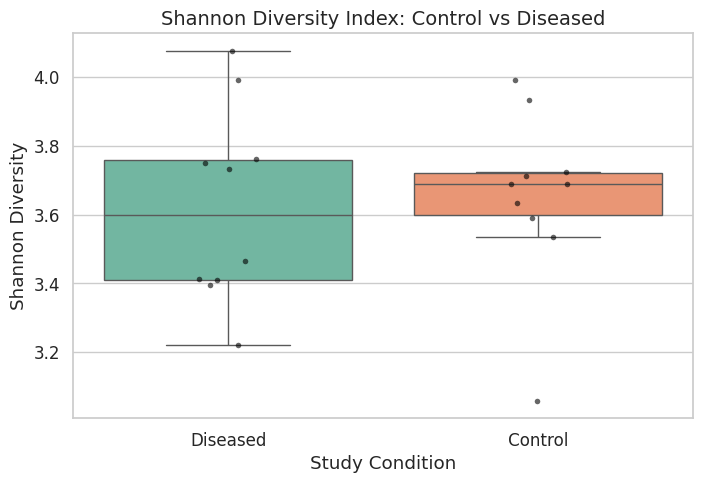

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ---- (A) Compare Control vs Diseased ----
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=alpha_df_meta,
    x="study_condition",
    y="shannon",
    hue="study_condition",
    dodge=False,
    showfliers=False
)

sns.stripplot(
    data=alpha_df_meta,
    x="study_condition",
    y="shannon",
    color="black",
    size=4,
    alpha=0.6
)
plt.title("Shannon Diversity Index: Control vs Diseased", fontsize=14)
plt.ylabel("Shannon Diversity")
plt.xlabel("Study Condition")
plt.legend([],[], frameon=False)

plt.savefig("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_by_study_condition.png", dpi=300, bbox_inches='tight')
plt.show()

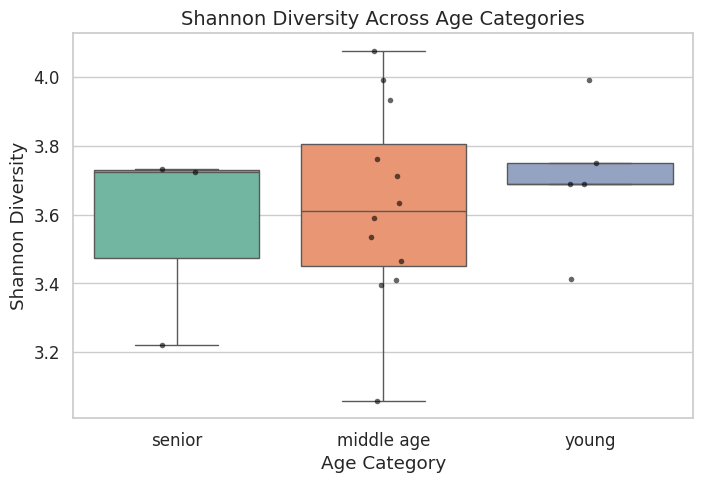

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ---- (B) Compare among age categories ----
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=alpha_df_meta,
    x="age_category",
    y="shannon",
    hue="age_category",
    dodge=False,
    showfliers=False
)
sns.stripplot(
    data=alpha_df_meta,
    x="age_category",
    y="shannon",
    color="black",
    size=4,
    alpha=0.6
)
plt.title("Shannon Diversity Across Age Categories", fontsize=14)
plt.ylabel("Shannon Diversity")
plt.xlabel("Age Category")
plt.legend([],[], frameon=False)

plt.savefig("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_by_age.png", dpi=300, bbox_inches='tight')

plt.show()


#Q1
##(iii) Use appropriate statistical tests to evaluate whether the observed differences are significant and represent them visually in your results.

In [ ]:
!pip install scikit-posthocs

In [ ]:
from scipy.stats import mannwhitneyu, kruskal
import scikit_posthocs as sp

In [ ]:
#Mann–Whitney U test for Control vs Diseased
# Separate groups
control = alpha_df_meta[alpha_df_meta['study_condition'] == 'Control']['shannon']
diseased = alpha_df_meta[alpha_df_meta['study_condition'] == 'Diseased']['shannon']

# Mann–Whitney U test
stat, p_value = mannwhitneyu(control, diseased, alternative='two-sided')

print(f"Mann–Whitney U test between Control and Diseased:")
print(f"Statistic = {stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in Shannon diversity between Control and Diseased groups.")
else:
    print("No significant difference found.")


Mann–Whitney U test between Control and Diseased:
Statistic = 51.0000, p-value = 0.9698
No significant difference found.


In [ ]:
##Kruskal–Wallis test for Age Categories
groups = [grp['shannon'].values for name, grp in alpha_df_meta.groupby('age_category')]
stat, p_value = kruskal(*groups)

print(f"\nKruskal–Wallis test across age categories:")
print(f"Statistic = {stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference detected among age categories.")
else:
    print("No significant difference detected among age categories.")



Kruskal–Wallis test across age categories:
Statistic = 0.4405, p-value = 0.8023
No significant difference detected among age categories.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Q1.
##(iv) Include statistical significance values on the plot, and provide a short interpretation of your findings.

In [ ]:
!pip install statannotations --quiet

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator

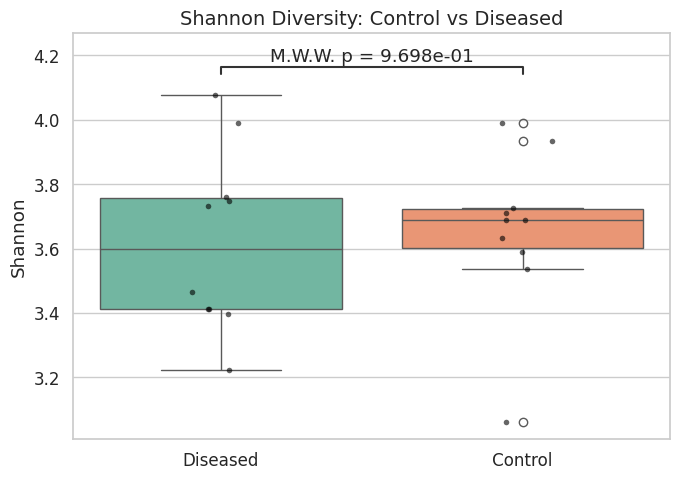

Saved: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_control_vs_diseased_full.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Full annotation (test name + p-value)
shannon_metric = 'shannon'
out_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_control_vs_diseased_full.png"

plt.figure(figsize=(7,5))
ax = sns.boxplot(
    data=alpha_df_meta,
    x='study_condition',
    y=shannon_metric,
    hue='study_condition',   # use hue to avoid palette warning
    palette='Set2',
    dodge=False,
    showfliers=True,
    legend=False
)
sns.stripplot(
    data=alpha_df_meta,
    x='study_condition',
    y=shannon_metric,
    color='black',
    size=4,
    alpha=0.6,
    jitter=True
)

# Define pair and let Annotator compute the test
pairs_cd = [("Control", "Diseased")]
annotator = Annotator(ax, pairs_cd, data=alpha_df_meta, x='study_condition', y=shannon_metric)

# Ask Annotator to perform Mann-Whitney test and display full text (test name + p-value)
annotator.configure(test='Mann-Whitney', text_format='full', loc='inside', verbose=0)
annotator.apply_test()     # compute test(s)
annotator.annotate()       # draw bars + text

ax.set_title("Shannon Diversity: Control vs Diseased", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Shannon")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out_path)


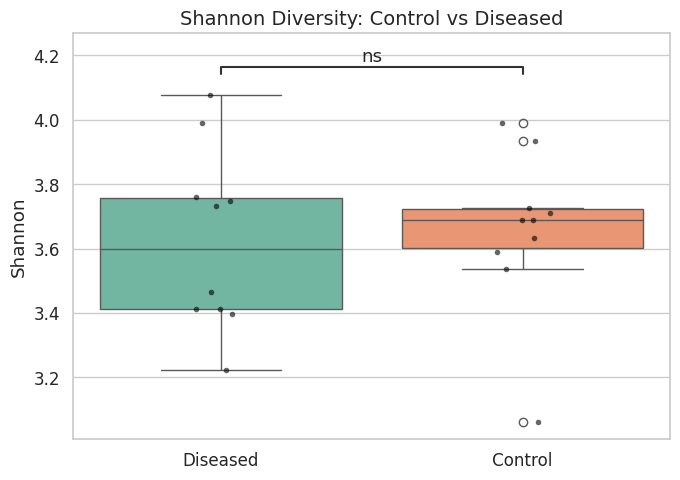

Saved: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_control_vs_diseased_star.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
## Star annotation
shannon_metric = 'shannon'
out_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_control_vs_diseased_star.png"

plt.figure(figsize=(7,5))
ax = sns.boxplot(
    data=alpha_df_meta,
    x='study_condition',
    y=shannon_metric,
    hue='study_condition',
    palette='Set2',
    dodge=False,
    showfliers=True,
    legend=False
)
sns.stripplot(
    data=alpha_df_meta,
    x='study_condition',
    y=shannon_metric,
    color='black',
    size=4,
    alpha=0.6,
    jitter=True
)

pairs_cd = [("Control", "Diseased")]
annotator = Annotator(ax, pairs_cd, data=alpha_df_meta, x='study_condition', y=shannon_metric)

# Ask Annotator to compute Mann-Whitney and show stars only
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=0)
annotator.apply_test()
annotator.annotate()

ax.set_title("Shannon Diversity: Control vs Diseased", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Shannon")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out_path)


/tmp/ipython-input-107157820.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=alpha_df_meta, x='age_category', y=metric, order=cats, showfliers=False, palette='Set3')


Kruskal-Wallis: H = 0.4405, p = 0.8023

Dunn (Bonferroni-corrected) p-value matrix:
             young  middle age  senior
young         1.0         1.0     1.0
middle age    1.0         1.0     1.0
senior        1.0         1.0     1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


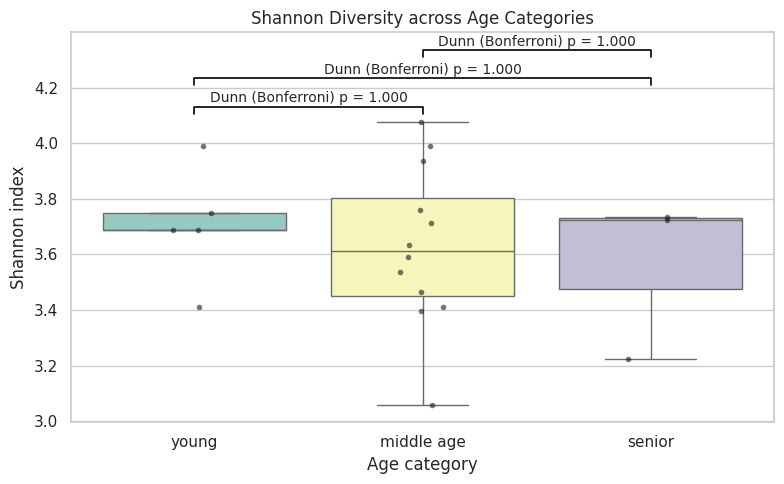

Saved: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_age_full.png


In [ ]:
#  ---— Full numeric p-values (recompute Kruskal + Dunn; draw bars and p-values manually)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import kruskal
from itertools import combinations

# Settings
metric = "shannon"
out_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_age_full.png"

# Prepare category order (preferable order first, fall back to whatever exists)
preferred = ['young', 'middle age', 'senior']
cats = [c for c in preferred if c in alpha_df_meta['age_category'].unique()] \
       + [c for c in alpha_df_meta['age_category'].unique() if c not in preferred]

# 1) Overall Kruskal-Wallis test
groups = [alpha_df_meta.loc[alpha_df_meta['age_category']==c, metric].dropna() for c in cats]
H, p_kw = kruskal(*groups)
print(f"Kruskal-Wallis: H = {H:.4f}, p = {p_kw:.4g}")

# 2) Dunn post-hoc with Bonferroni correction
posthoc = sp.posthoc_dunn(alpha_df_meta, val_col=metric, group_col='age_category', p_adjust='bonferroni')
posthoc = posthoc.reindex(index=cats, columns=cats)  # ensure consistent order
print("\nDunn (Bonferroni-corrected) p-value matrix:\n", posthoc)

# 3) Plot boxplot + points
sns.set(style="whitegrid", font_scale=1.0)
plt.figure(figsize=(8,5))
ax = sns.boxplot(data=alpha_df_meta, x='age_category', y=metric, order=cats, showfliers=False, palette='Set3')
sns.stripplot(data=alpha_df_meta, x='age_category', y=metric, order=cats,
              color='k', size=4, alpha=0.6, jitter=True)
ax.set_title("Shannon Diversity across Age Categories")
ax.set_xlabel("Age category")
ax.set_ylabel("Shannon index")

# 4) Manual annotation: draw bars and add Dunn p-values
pairs = list(combinations(range(len(cats)), 2))  # index pairs: (0,1), (0,2), (1,2)
ymin, ymax = alpha_df_meta[metric].min(), alpha_df_meta[metric].max()
height_step = (ymax - ymin) * 0.10  # vertical spacing between pair bars
base_y = ymax + (ymax - ymin) * 0.03

for i, (i1, i2) in enumerate(pairs):
    cat1, cat2 = cats[i1], cats[i2]
    pval = posthoc.loc[cat1, cat2]
    if np.isnan(pval):
        label = "n/a"
    else:
        label = f"Dunn (Bonferroni) p = {pval:.3f}"
    # compute coordinates
    y = base_y + i * height_step
    ybar = y + (height_step * 0.25)
    x1, x2 = i1, i2
    ax.plot([x1, x1, x2, x2], [y, ybar, ybar, y], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, ybar + (height_step * 0.05), label, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out_path)


/tmp/ipython-input-1314476680.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=alpha_df_meta, x='age_category', y=metric, order=cats, showfliers=False, palette='Set3')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12

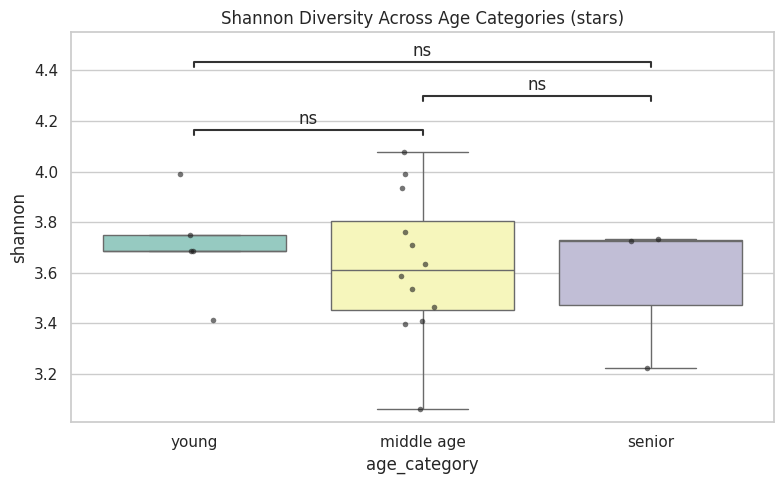

Saved: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_age_star.png


In [ ]:
#  ---— Star annotations using statannotations (recompute Dunn; feed corrected p-values to Annotator)
!pip install scikit-posthocs statannotations --quiet

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from statannotations.Annotator import Annotator
from itertools import combinations

# Settings
metric = "shannon"
out_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q1/shannon_age_star.png"

# Category ordering (same logic as Block A)
preferred = ['young', 'middle age', 'senior']
cats = [c for c in preferred if c in alpha_df_meta['age_category'].unique()] \
       + [c for c in alpha_df_meta['age_category'].unique() if c not in preferred]

# 1) Compute Dunn (Bonferroni)
posthoc = sp.posthoc_dunn(alpha_df_meta, val_col=metric, group_col='age_category', p_adjust='bonferroni')
posthoc = posthoc.reindex(index=cats, columns=cats)

# 2) Build list of pairs and p-values (replace NaN with 1.0 so Annotator treats as ns)
pairs = [(cats[i], cats[j]) for i,j in combinations(range(len(cats)), 2)]
pvals = [posthoc.loc[a,b] if not np.isnan(posthoc.loc[a,b]) else 1.0 for (a,b) in pairs]

# 3) Plot
plt.figure(figsize=(8,5))
ax = sns.boxplot(data=alpha_df_meta, x='age_category', y=metric, order=cats, showfliers=False, palette='Set3')
sns.stripplot(data=alpha_df_meta, x='age_category', y=metric, order=cats, color='k', size=4, alpha=0.6, jitter=True)

# 4) Annotate with stars using statannotations (we provide p-values; test=None because we precomputed)
annot = Annotator(ax, pairs, data=alpha_df_meta, x='age_category', y=metric, order=cats)
annot.configure(test=None, text_format='star', loc='inside', verbose=0)
annot.set_pvalues(pvals)
annot.annotate()

ax.set_title("Shannon Diversity Across Age Categories (stars)")
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out_path)


# Question 2: Examining overall community-level differences in microbial composition between samples.

In [ ]:
# !pip install scikit-bio seaborn matplotlib pandas

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skbio import DistanceMatrix
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## (i) Compute the Bray-Curtis dissimilarity between all the microbiomes using the species abundance matrix. Visualize the results using Principal Coordinates Analysis (PCoA).

Requested sample IDs (n=20): 20
Found 20 of 20 requested samples in abundance_df.
Saved bray_curtis_subset_batch3.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:157: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/usr/local/lib/python3.12/dist-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:275: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.015741119259345713 whereas the largest positive one is 0.7989294968500804.
  warn(
/usr/local/

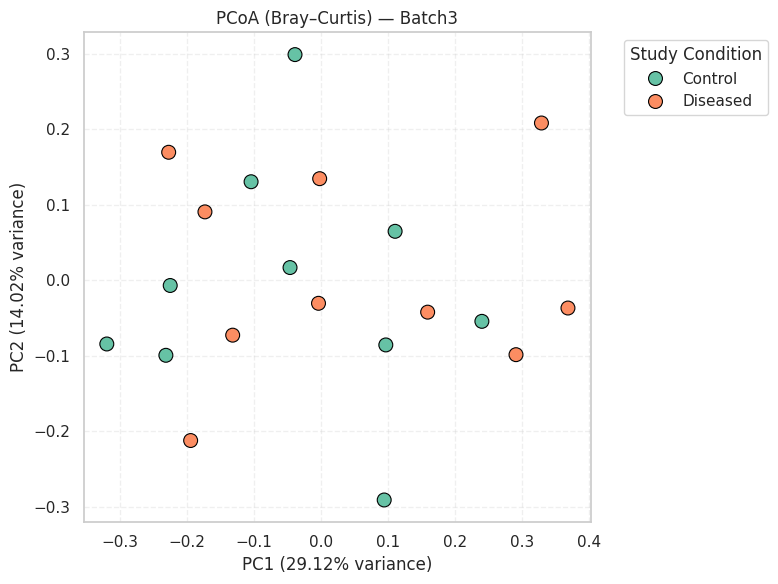

✅ PCoA plot saved successfully as: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/PCoA_BrayCurtis_Batch3.png


In [ ]:
# --- Step 1: get the 20 target ids from batch_df
target_ids = batch_df['sample_id'].astype(str).unique().tolist()
print(f"Requested sample IDs (n={len(target_ids)}): {len(target_ids)}")

# --- Step 2: ensure abundance_df index is string sample IDs
# If sample IDs are a column instead of index, try to set it:
if 'sample_id' in abundance_df.columns:
    abundance_df = abundance_df.set_index('sample_id')

abundance_df.index = abundance_df.index.astype(str)

# --- Step 3: find intersection and report missing IDs
present_ids = [sid for sid in target_ids if sid in abundance_df.index]
missing_ids = [sid for sid in target_ids if sid not in abundance_df.index]

print(f"Found {len(present_ids)} of {len(target_ids)} requested samples in abundance_df.")
if missing_ids:
    print("Missing sample IDs (not found in abundance_df):")
    for m in missing_ids:
        print(" ", m)

# Proceed only with present IDs
if len(present_ids) == 0:
    raise ValueError("No requested sample IDs were found in abundance_df. Please check IDs and indexes.")

subset_abundance = abundance_df.loc[present_ids].copy()

# --- Step 4: ensure abundance values are numeric and fill NAs with 0
subset_abundance = subset_abundance.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Step 5: align metadata (alpha_df_meta) to the subset
# Make sure metadata index is string too (and either already has sample IDs as index, or a column 'sample_id')
if 'sample_id' in alpha_df_meta.columns:
    alpha_df_meta = alpha_df_meta.set_index('sample_id')
alpha_df_meta.index = alpha_df_meta.index.astype(str)

meta_sub = alpha_df_meta.reindex(subset_abundance.index)

# Report any samples with missing metadata
meta_missing = meta_sub[meta_sub.isnull().all(axis=1)]
if len(meta_missing) > 0:
    print(f"Warning: {len(meta_missing)} samples have missing metadata rows in alpha_df_meta.")
    print(meta_missing.index.tolist())

# --- Step 6: compute Bray-Curtis distance matrix for the subset
bray_curtis_dm = beta_diversity(
    metric='braycurtis',
    counts=subset_abundance.values,
    ids=subset_abundance.index.tolist()
)

# Convert to DataFrame (optional save)
bray_df = pd.DataFrame(bray_curtis_dm.data, index=bray_curtis_dm.ids, columns=bray_curtis_dm.ids)
bray_df.to_csv("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/bray_curtis_subset_batch3.csv")
print("Saved bray_curtis_subset_batch3.csv")


# --- Step 7: PCoA
pcoa_res = pcoa(bray_curtis_dm)
pcoa_coords = pcoa_res.samples.copy()
pcoa_coords.index = pcoa_coords.index.astype(str)

# merge study_condition (or other metadata) for plotting
if 'study_condition' not in meta_sub.columns:
    raise KeyError("'study_condition' not found in alpha_df_meta. Please check metadata column names.")

pcoa_coords['study_condition'] = meta_sub.loc[pcoa_coords.index, 'study_condition'].values

# explained variance
explained = pcoa_res.proportion_explained * 100

# --- Step 8: Plot PCoA colored by study_condition and save figure

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pcoa_coords,
    x='PC1', y='PC2',
    hue='study_condition',
    s=100,
    palette='Set2',
    edgecolor='black'
)

plt.xlabel(f"PC1 ({explained[0]:.2f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.2f}% variance)")
plt.title("PCoA (Bray–Curtis) — Batch3")
plt.legend(title='Study Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# Save plot
output_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/PCoA_BrayCurtis_Batch3.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"✅ PCoA plot saved successfully as: {output_path}")


#Q2.
## (ii) Perform a suitable statistical test on the computed Bray-Curtis distances to assess whether microbial community structure differs by ‘age_category’ (young, middle age, senior), ‘study_condition’ (Control and Diseased) and ‘gender’ (male and female) as per the given metadata. Report the statistical significance and the strength of separation from the statistical test applied. Infer the results properly.

In [ ]:
from skbio.diversity import beta_diversity
from skbio.stats.distance import permanova

# Filter data for the 20 Batch3 samples
batch_samples = batch_df["sample_id"].tolist()
batch_abundance = abundance_df.loc[batch_samples]

# Ensure metadata matches these samples
batch_meta = alpha_df_meta.loc[batch_samples]

# Compute Bray–Curtis distance matrix
distance_matrix = beta_diversity(
    metric="braycurtis",
    counts=batch_abundance.values,
    ids=batch_abundance.index
)

# Run PERMANOVA for each metadata variable
for factor in ["study_condition", "age_category", "gender"]:
    result = permanova(distance_matrix, batch_meta[factor], permutations=999)
    print(f"\nPERMANOVA results for {factor}:")
    print(result)



PERMANOVA results for study_condition:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      20
number of groups                  2
test statistic             0.977732
p-value                       0.445
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA results for age_category:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      20
number of groups                  3
test statistic             0.707963
p-value                       0.848
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA results for gender:
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      20
number of groups                  2
test statistic             1.388349
p-value                       0.143
number of permutations          999
Name: PERMANOVA results, dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Q2.
## (iii) Compare the within-group and between-group Bray-Curtis dissimilarities for the Control and Diseased groups using a statistical test and show them as boxplots. Compare their average dissimilarity values and infer properly.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


Mann–Whitney U test:
Statistic = 4584.000, p-value = 0.8254


/tmp/ipython-input-1404195077.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x="Group", y="Distance", palette="Set2", width=0.6)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


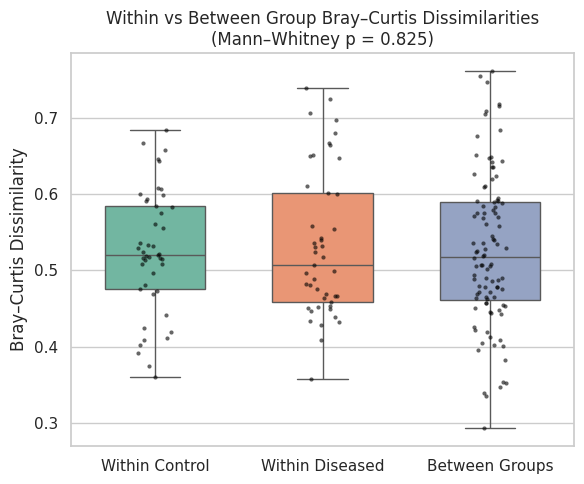

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Step 1: Align metadata and distance matrix ---
# Ensure consistent index formats
alpha_df_meta.index = alpha_df_meta.index.astype(str)
distance_ids = [str(i) for i in distance_matrix.ids]

# Subset metadata for the same samples (in same order)
conditions = alpha_df_meta.reindex(distance_ids)["study_condition"]

# --- Step 2: Convert Bray–Curtis distance matrix to DataFrame ---
dist_df = pd.DataFrame(distance_matrix.data,
                       index=distance_matrix.ids,
                       columns=distance_matrix.ids)

# --- Step 3: Collect within-group and between-group distances ---
within_control = []
within_diseased = []
between_groups = []

for i in range(len(dist_df)):
    for j in range(i + 1, len(dist_df)):
        s1, s2 = dist_df.index[i], dist_df.index[j]
        cond1, cond2 = conditions[s1], conditions[s2]
        d = dist_df.iloc[i, j]

        if cond1 == "Control" and cond2 == "Control":
            within_control.append(d)
        elif cond1 == "Diseased" and cond2 == "Diseased":
            within_diseased.append(d)
        else:
            between_groups.append(d)

# --- Step 4: Create tidy DataFrame for plotting ---
box_df = pd.DataFrame({
    "Distance": within_control + within_diseased + between_groups,
    "Group": (["Within Control"] * len(within_control)) +
             (["Within Diseased"] * len(within_diseased)) +
             (["Between Groups"] * len(between_groups))
})

# --- Step 5: Statistical comparison (Mann–Whitney U test) ---
stat, p_value = mannwhitneyu(
    within_control + within_diseased, between_groups, alternative="two-sided"
)

print(f"Mann–Whitney U test:\nStatistic = {stat:.3f}, p-value = {p_value:.4f}")

# --- Step 6: Boxplot visualization ---
plt.figure(figsize=(6, 5))
sns.boxplot(data=box_df, x="Group", y="Distance", palette="Set2", width=0.6)
sns.stripplot(data=box_df, x="Group", y="Distance", color="black", size=3, jitter=True, alpha=0.6)
plt.title(f"Within vs Between Group Bray–Curtis Dissimilarities\n(Mann–Whitney p = {p_value:.3f})")
plt.ylabel("Bray–Curtis Dissimilarity")
plt.xlabel("")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/BrayCurtis_Within_Between_Boxplot.png", dpi=300)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Assuming 'within_control', 'within_diseased', and 'between_groups' arrays are already defined
# (same ones used for the boxplot)

# Create a DataFrame for easy summary
summary_df = pd.DataFrame({
    'Group': ['Within Control', 'Within Diseased', 'Between Groups'],
    'Mean Bray–Curtis Dissimilarity': [
        np.mean(within_control),
        np.mean(within_diseased),
        np.mean(between_groups)
    ],
    'SD Bray–Curtis Dissimilarity': [
        np.std(within_control),
        np.std(within_diseased),
        np.std(between_groups)
    ]
})

# Round for cleaner display
summary_df = summary_df.round(4)
summary_df

,Group,Mean Bray–Curtis Dissimilarity,SD Bray–Curtis Dissimilarity
0,Within Control,0.5242,0.0798
1,Within Diseased,0.5326,0.0951
2,Between Groups,0.5258,0.0995


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#Q2.
## (iv) Test whether ‘study_condition’ affects microbial beta diversity using a suitable non-parametric statistical test that can be used for multivariate analysis, controlling for ‘age’ as a covariate. Infer the result properly.

In [194]:
import os, shutil, subprocess, sys, textwrap

# Output directory for Q2
out_dir = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2"
os.makedirs(out_dir, exist_ok=True)

# ✅ Correct input CSVs based on your folder listing
abundance_fp = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/species_profile_norm.csv"
metadata_fp  = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/metadata_all.csv"
batch_fp     = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/Batch3.csv"

# Paths for R script and output
r_script_path = os.path.join(out_dir, "run_adonis2.R")
r_output_path = os.path.join(out_dir, "adonis2_output.txt")

def ensure_rscript():
    rscript = shutil.which("Rscript")
    if rscript:
        return rscript
    raise RuntimeError("Rscript not found. Please install R and ensure Rscript is on PATH.")

def write_r_script(rpath, abund_fp, meta_fp, batch_fp, out_txt):
    r_code = f"""
    suppressMessages(library(vegan))
    abund_fp <- "{abund_fp}"
    meta_fp  <- "{meta_fp}"
    batch_fp <- "{batch_fp}"

    abund <- read.csv(abund_fp, row.names=1, check.names=FALSE, stringsAsFactors=FALSE)
    meta  <- read.csv(meta_fp, stringsAsFactors=FALSE)
    batch <- read.csv(batch_fp, stringsAsFactors=FALSE)

    # Normalize column names
    if(!"sample_id" %in% colnames(meta)) {{
      candidate <- NULL
      for(cn in colnames(meta)) {{
        if(tolower(cn) %in% c("sampleid","sample_id","sample","id")) {{
          candidate <- cn; break
        }}
      }}
      if(!is.null(candidate)) {{
        colnames(meta)[colnames(meta) == candidate] <- "sample_id"
      }}
    }}

    ids <- as.character(batch$sample_id)
    avail <- ids[ids %in% rownames(abund)]
    if(length(avail) == 0) stop("No batch samples found in abundance file.")

    abund_sub <- abund[avail, , drop=FALSE]
    meta_sub  <- meta[meta$sample_id %in% avail, , drop=FALSE]
    rownames(meta_sub) <- as.character(meta_sub$sample_id)

    if(!"age" %in% colnames(meta_sub)) stop("Column 'age' not found in metadata.")
    meta_sub$age <- as.numeric(meta_sub$age)

    # ✅ Bray–Curtis PERMANOVA controlling for age
    bray <- vegdist(abund_sub, method="bray")
    adon_res <- adonis2(bray ~ study_condition + age, data=meta_sub, permutations=999, by="margin")

    cat("---- adonis2 results (study_condition + age) ----\\n")
    print(adon_res)
    write.table(capture.output(adon_res), file="{out_txt}", row.names=FALSE, col.names=FALSE)
    """
    with open(rpath, "w") as fh:
        fh.write(textwrap.dedent(r_code))
    print(f"✅ R script written to: {rpath}")

def run_rscript_and_capture(rscript_exec, rpath):
    print(f"🚀 Running: {rscript_exec} {rpath}")
    proc = subprocess.Popen([rscript_exec, rpath], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in proc.stdout:
        sys.stdout.write(line)
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"Rscript exited with code {proc.returncode}. Check output above.")

def main():
    r_exec = ensure_rscript()
    write_r_script(r_script_path, abundance_fp, metadata_fp, batch_fp, r_output_path)
    run_rscript_and_capture(r_exec, r_script_path)
    print(f"\n📄 Full results saved to: {r_output_path}")

if __name__ == "__main__":
    main()


✅ R script written to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/run_adonis2.R
🚀 Running: /usr/bin/Rscript /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/run_adonis2.R
---- adonis2 results (study_condition + age) ----
Permutation test for adonis under reduced model
Marginal effects of terms
Permutation: free
Number of permutations: 999

adonis2(formula = bray ~ study_condition + age, data = meta_sub, permutations = 999, by = "margin")
                Df SumOfSqs      R2      F Pr(>F)
study_condition  1  0.13470 0.04947 0.9407  0.447
age              1  0.16522 0.06068 1.1538  0.272
Residual        17  2.43432 0.89405              
Total           19  2.72278 1.00000              

📄 Full results saved to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q2/adonis2_output.txt


# Q3. (Goal 1)
## Q i. **Wilcoxon / Mann–Whitney U test per species (Disease** vs Control)

In [ ]:
# 1) Imports + parameters
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Parameters / expected column names
BATCH_SAMPLE_COL = "sample_id"   # expected in batch_df
META_SAMPLE_COL = "sample_id"    # expected in alpha_df_meta
CONDITION_COL = "study_condition"  # expected values: "Control" and "Diseased"
OUTPUT_CSV = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1.csv"

print("Ready. Parameters set:")
print(" - BATCH_SAMPLE_COL:", BATCH_SAMPLE_COL)
print(" - META_SAMPLE_COL:", META_SAMPLE_COL)
print(" - CONDITION_COL:", CONDITION_COL)
print(" - OUTPUT_CSV:", OUTPUT_CSV)


Ready. Parameters set:
 - BATCH_SAMPLE_COL: sample_id
 - META_SAMPLE_COL: sample_id
 - CONDITION_COL: study_condition
 - OUTPUT_CSV: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1.csv


In [ ]:
# 2) Sanity: check objects exist and show shapes
for name in ["abundance_df", "alpha_df_meta", "batch_df"]:
    if name not in globals():
        raise RuntimeError(f"Required object '{name}' not found in notebook environment.")
    else:
        obj = globals()[name]
        try:
            print(f"{name}.shape ->", obj.shape)
        except Exception:
            print(f"{name} found (cannot show shape). Type: {type(obj)}")

# Show first few columns/sample IDs for abundance_df
print("\nabundance_df: index sample example (first 6):", list(abundance_df.index.astype(str)[:6]))
print("abundance_df: number of species (columns):", abundance_df.shape[1])

abundance_df.shape -> (265, 777)
alpha_df_meta.shape -> (20, 7)
batch_df.shape -> (20, 4)

abundance_df: index sample example (first 6): ['ERR4043609', 'ERR4042941', 'ERR4043202', 'ERR4043130', 'ERR4043776', 'ERR4042921']
abundance_df: number of species (columns): 777


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 3) Inspect batch_df and alpha_df_meta to confirm sample id column/index
print("batch_df columns:", list(batch_df.columns))
print("batch_df.head():")
display(batch_df.head())

print("\nalpha_df_meta columns:", list(alpha_df_meta.columns))
print("alpha_df_meta.head():")
display(alpha_df_meta.head())

batch_df columns: ['sample_id', 'gender', 'study_condition', 'age_category']
batch_df.head():


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,sample_id,gender,study_condition,age_category
0,ERR4043366,male,Control,young
1,ERR4043596,male,Control,middle age
2,ERR4043606,female,Control,middle age
3,ERR4043608,male,Control,middle age
4,ERR4043806,male,Control,middle age



alpha_df_meta columns: ['observed_species', 'shannon', 'simpson', 'gender', 'study_condition', 'age_category', 'age']
alpha_df_meta.head():


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,observed_species,shannon,simpson,gender,study_condition,age_category,age
sample_id,,,,,,,
ERR4042941,195,3.733426,0.954429,male,Diseased,senior,88
ERR4042921,151,3.410749,0.941204,male,Diseased,middle age,60
ERR4043188,164,3.464546,0.944895,male,Diseased,middle age,48
ERR4043295,161,3.760363,0.959638,female,Diseased,middle age,41
ERR4043366,166,3.687509,0.955467,male,Control,young,30


In [ ]:
# 4) Build selected_samples robustly (Batch3 ∩ abundance_df.index ∩ alpha_df_meta sample ids)
# Get batch sample ids (column or index)
if BATCH_SAMPLE_COL in batch_df.columns:
    batch_ids = batch_df[BATCH_SAMPLE_COL].astype(str).tolist()
else:
    batch_ids = batch_df.index.astype(str).tolist()
    print(f"Note: using batch_df.index as sample IDs (found {len(batch_ids)})")

# Get metadata sample ids (column or index)
if META_SAMPLE_COL in alpha_df_meta.columns:
    meta_ids = alpha_df_meta[META_SAMPLE_COL].astype(str).tolist()
else:
    meta_ids = alpha_df_meta.index.astype(str).tolist()
    print(f"Note: using alpha_df_meta.index as sample IDs (found {len(meta_ids)})")

# abundance sample ids
abund_ids = abundance_df.index.astype(str).tolist()

# intersection
selected_samples = sorted(list(set(batch_ids) & set(meta_ids) & set(abund_ids)))
print("Selected samples (Batch3 ∩ abundance ∩ meta):", len(selected_samples))
print("Example selected sample IDs (first 10):", selected_samples[:10])

if len(selected_samples) == 0:
    raise ValueError("No overlapping Batch3 samples found between batch_df, abundance_df, and alpha_df_meta.")

Note: using alpha_df_meta.index as sample IDs (found 20)
Selected samples (Batch3 ∩ abundance ∩ meta): 20
Example selected sample IDs (first 10): ['ERR4042824', 'ERR4042849', 'ERR4042883', 'ERR4042921', 'ERR4042941', 'ERR4042949', 'ERR4043086', 'ERR4043188', 'ERR4043295', 'ERR4043299']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 5) Subset and align
abund_batch3 = abundance_df.loc[selected_samples].copy()
# Build meta_batch3 with sample_id as index in same order
if META_SAMPLE_COL in alpha_df_meta.columns:
    meta_batch3 = alpha_df_meta.set_index(META_SAMPLE_COL).loc[selected_samples].copy()
else:
    meta_batch3 = alpha_df_meta.copy()
    meta_batch3.index = meta_batch3.index.astype(str)
    meta_batch3 = meta_batch3.loc[selected_samples]

print("abund_batch3.shape:", abund_batch3.shape)
print("meta_batch3.shape:", meta_batch3.shape)

# Row-sum normalization to relative abundances (idempotent)
row_sums = abund_batch3.sum(axis=1)
if (row_sums == 0).any():
    print("Warning: some samples have row-sum 0; they will be set to zeros after normalization.")
abund_norm_batch3 = abund_batch3.div(row_sums.replace({0: np.nan}), axis=0).fillna(0)

# Quick check: row-sums should be ~1
rs = abund_norm_batch3.sum(axis=1)
print("Row-sum stats after normalization (should be ~1):")
print(rs.describe())

abund_batch3.shape: (20, 777)
meta_batch3.shape: (20, 7)
Row-sum stats after normalization (should be ~1):
count    2.000000e+01
mean     1.000000e+00
std      7.099764e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 6) Group counts and species presence check
if CONDITION_COL not in meta_batch3.columns:
    raise KeyError(f"Expected condition column '{CONDITION_COL}' not found in meta_batch3. Columns: {list(meta_batch3.columns)}")

group_series = meta_batch3[CONDITION_COL].astype(str)
print("Study condition counts in Batch3:")
print(group_series.value_counts())

control_samples = group_series[group_series == "Control"].index.tolist()
disease_samples = group_series[group_series == "Diseased"].index.tolist()
print(f"Control samples: {len(control_samples)}, Diseased samples: {len(disease_samples)}")

# count species present (non-zero) in both groups
species_present_both = []
for sp in abund_norm_batch3.columns:
    pres_c = (abund_norm_batch3.loc[control_samples, sp] > 0).any()
    pres_d = (abund_norm_batch3.loc[disease_samples, sp] > 0).any()
    if pres_c and pres_d:
        species_present_both.append(sp)

print("Species present in both groups (will be tested):", len(species_present_both))
# show a few example species
print("Example species to be tested (first 10):", species_present_both[:10])

Study condition counts in Batch3:
study_condition
Diseased    10
Control     10
Name: count, dtype: int64
Control samples: 10, Diseased samples: 10


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Species present in both groups (will be tested): 268
Example species to be tested (first 10): ['Kingella_potus', 'Streptococcus_oligofermentans', 'Lachnoanaerobaculum_orale', 'Sphaerochaeta_globosa', 'Selenomonas_noxia', 'Pyramidobacter_piscolens', 'Porphyromonas_catoniae', 'Leptotrichia_buccalis', 'Bergeriella_denitrificans', 'Aggregatibacter_actinomycetemcomitans']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 7) Mann-Whitney U tests and save
results = []
for sp in abund_norm_batch3.columns:
    vals_c = abund_norm_batch3.loc[control_samples, sp].values
    vals_d = abund_norm_batch3.loc[disease_samples, sp].values

    present_c = np.any(vals_c > 0)
    present_d = np.any(vals_d > 0)

    if not (present_c and present_d):
        pval = np.nan
    else:
        try:
            stat, pval = mannwhitneyu(vals_d, vals_c, alternative="two-sided")
        except Exception:
            pval = np.nan

    results.append((sp, pval))

diff_abundance_stats_subq1 = pd.DataFrame(results, columns=["species", "p_value"]).set_index("species")

# Save
diff_abundance_stats_subq1.to_csv(OUTPUT_CSV)
print(f"Saved results to {OUTPUT_CSV}")
print("Number of species tested (non-NA p-values):", diff_abundance_stats_subq1['p_value'].notna().sum())
print("P-value summary (non-NA):")
print(diff_abundance_stats_subq1['p_value'].describe())

# Keep results in notebook namespace for next subquestions
diff_abundance_stats_subq1.head()

Saved results to /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1.csv
Number of species tested (non-NA p-values): 268
P-value summary (non-NA):
count    268.000000
mean       0.503777
std        0.301803
min        0.018661
25%        0.231216
50%        0.503631
75%        0.733730
max        1.000000
Name: p_value, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,p_value
species,
Vibrio_alginolyticus,NaN
Clostridium_saccharolyticum,NaN
Dyadobacter_fermentans,NaN
Selenomonas_bovis,NaN
Prevotella_dentalis,NaN


Ans. Q3(i)
A Wilcoxon rank-sum test (Mann–Whitney U) was performed on 268 species present in both groups (10 Control vs 10 Diseased, Batch 3); p-values were saved in diff_abundance_stats_batch3_subq1.csv and show no widespread strong differences (p-value mean ≈ 0.50), with a few species warranting further follow-up after multiple-testing correction.

Question 2. Calculate the mean abundance in each group (Disease and Control)

In [ ]:
# Cell 1 — checks and file paths (run once)
import numpy as np
import pandas as pd

# Names used earlier in your notebook
ABUND_NORM = "abund_norm_batch3"          # normalized abundance df (samples x species)
META = "meta_batch3"                      # metadata for Batch3 with sample_id as index
RESULTS_DF = "diff_abundance_stats_subq1" # results df produced earlier
OUTPUT_MEANS_CSV = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1_with_means.csv"

# Quick availability checks
for name in [ABUND_NORM, META, RESULTS_DF]:
    if name not in globals():
        raise RuntimeError(f"Required object '{name}' not found in the notebook environment. Make sure you ran prior cells.")
print("All required objects present. Will write updated results to:", OUTPUT_MEANS_CSV)

All required objects present. Will write updated results to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1_with_means.csv


In [ ]:
# Cell 2 — build group sample lists and show counts
abund = globals()[ABUND_NORM]   # samples x species, index = sample_id
meta = globals()[META]          # metadata for Batch3, index = sample_id
results = globals()[RESULTS_DF] # existing results, index = species

# Ensure study_condition exists
if "study_condition" not in meta.columns:
    raise KeyError("Column 'study_condition' not found in meta_batch3")

control_samples = meta[meta["study_condition"] == "Control"].index.tolist()
disease_samples = meta[meta["study_condition"] == "Diseased"].index.tolist()

print("Group counts (Batch3):")
print(" - Control:", len(control_samples))
print(" - Diseased:", len(disease_samples))

# quick sanity: sample IDs present in abund
missing_in_abund = [s for s in control_samples + disease_samples if s not in abund.index]
if missing_in_abund:
    print("Warning: the following Batch3 samples are missing in abund_norm_batch3:", missing_in_abund)
else:
    print("All group samples present in abund_norm_batch3.")

Group counts (Batch3):
 - Control: 10
 - Diseased: 10
All group samples present in abund_norm_batch3.


In [ ]:
# Cell 3 — compute mean(Control) and mean(Diseased) per species and save
abund = globals()[ABUND_NORM]
results = globals()[RESULTS_DF]

# compute means (species are columns in abund)
mean_control = abund.loc[control_samples].mean(axis=0)   # Series indexed by species
mean_diseased = abund.loc[disease_samples].mean(axis=0)

# Align names: abund columns may be species names; results index should match
# If results index has species formatted differently (e.g., spaces vs underscores), ensure alignment.
# Here we assume column names match results.index; if not, we'll do reindex which will introduce NaN.
print("Number of species in abund columns:", abund.shape[1])
print("Number of species in results df:", results.shape[0])

# Create a dataframe of means and merge/assign into results df
means_df = pd.DataFrame({
    "mean_control": mean_control,
    "mean_diseased": mean_diseased
})

# Reindex means_df to results.index to ensure same order and include only tested species
means_df = means_df.reindex(results.index)

# Add columns to results (will create NaN for species not found in abund columns)
results_with_means = results.copy()
results_with_means["mean_control"] = means_df["mean_control"]
results_with_means["mean_diseased"] = means_df["mean_diseased"]

# Save and display a small preview
results_with_means.to_csv(OUTPUT_MEANS_CSV)
print("Saved results with mean abundances to:", OUTPUT_MEANS_CSV)
print("Preview (first 8 rows):")
display(results_with_means.head(8))

# Keep updated dataframe in notebook namespace (overwrite previous var for convenience)
diff_abundance_stats_subq1 = results_with_means

Number of species in abund columns: 777
Number of species in results df: 777
Saved results with mean abundances to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq1_with_means.csv
Preview (first 8 rows):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,p_value,mean_control,mean_diseased
species,,,
Vibrio_alginolyticus,NaN,0.000000,0.000000
Clostridium_saccharolyticum,NaN,0.000000,0.000000
Dyadobacter_fermentans,NaN,0.000000,0.000003
Selenomonas_bovis,NaN,0.000000,0.000000
Prevotella_dentalis,NaN,0.000008,0.000000
Kingella_potus,0.570170,0.000470,0.001094
Microlunatus_soli,NaN,0.000000,0.000000
Streptococcus_oligofermentans,0.101161,0.000046,0.000002


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Question 3. Determine the directionality of change [1 if mean(Disease) > mean(Control); -1
if mean(Disease) < mean(Control); 0 if they are equal]

In [ ]:
# Compute directionality
diff_abundance_stats_subq1["direction"] = diff_abundance_stats_subq1.apply(
    lambda row: 1 if row["mean_diseased"] > row["mean_control"]
    else (-1 if row["mean_diseased"] < row["mean_control"] else 0),
    axis=1
)

# Check distribution of direction values
direction_counts = diff_abundance_stats_subq1["direction"].value_counts(dropna=False)
print("\nDirectionality summary:")
print(direction_counts)

# Save the updated file
out_path_subq3 = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq3.csv"
diff_abundance_stats_subq1.to_csv(out_path_subq3)

print(f"\n✅ Saved updated results with directionality to: {out_path_subq3}")


Directionality summary:
direction
 0    397
 1    215
-1    165
Name: count, dtype: int64

✅ Saved updated results with directionality to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq3.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Question 4. Compute the FDR-adjusted p-value (Q-value) to correct for multiple testing.


In [ ]:
# Compute FDR-adjusted p-values (Q-values) for subquestion (iv)

from statsmodels.stats.multitest import multipletests

# Use only valid p-values
valid_pvals = diff_abundance_stats_subq1['p_value'].dropna()

# Apply Benjamini–Hochberg FDR correction
_, qvals, _, _ = multipletests(valid_pvals, method='fdr_bh')

# Assign q-values back
diff_abundance_stats_subq1.loc[valid_pvals.index, 'q_value'] = qvals

# Print quick summary
print("Q-value summary:")
print(diff_abundance_stats_subq1['q_value'].dropna().describe())

# Counts of significant species
print(f"\nSignificant species (q < 0.05): {(diff_abundance_stats_subq1['q_value'] < 0.05).sum()}")
print(f"Significant species (q < 0.10): {(diff_abundance_stats_subq1['q_value'] < 0.10).sum()}")

# Save
out_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq4_qvalues.csv"
diff_abundance_stats_subq1.to_csv(out_path)
print(f"\nSaved with q_values to: {out_path}")


Q-value summary:
count    268.000000
mean       0.934066
std        0.045872
min        0.873975
25%        0.873975
50%        0.930001
75%        0.968668
max        1.000000
Name: q_value, dtype: float64

Significant species (q < 0.05): 0
Significant species (q < 0.10): 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Saved with q_values to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_subq4_qvalues.csv


Question 5. Calculate the log₂ fold change (log₂FC) with respect to Disease


In [ ]:
# Compute log2 fold change and produce exploratory top-10 tables
import numpy as np
import pandas as pd

# Parameters
pseudocount = 1e-6
out_full = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_with_log2FC.csv"
out_top_p = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/top10_by_pvalue_exploratory.csv"
out_top_fc = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/top10_by_abslog2fc_exploratory.csv"

# Ensure the dataframe exists
df = diff_abundance_stats_subq1.copy()

# Check we have mean_control and mean_diseased
if ("mean_control" not in df.columns) or ("mean_diseased" not in df.columns):
    raise RuntimeError("mean_control and/or mean_diseased columns missing. Run subquestion (ii) code first.")

# Compute log2FC (Disease relative to Control)
df["log2FC"] = np.log2((df["mean_diseased"] + pseudocount) / (df["mean_control"] + pseudocount))

# Save full updated table
df.to_csv(out_full)
print(f"Saved full table with log2FC to: {out_full}")

# Prepare exploratory top-10 by unadjusted p-value (exclude NaN p-values)
top_by_p = df.dropna(subset=["p_value"]).sort_values("p_value", ascending=True).head(10)
top_by_p = top_by_p[["p_value", "q_value", "mean_control", "mean_diseased", "direction", "log2FC"]]

# Prepare exploratory top-10 by absolute log2FC (exclude NaNs)
top_by_fc = df.dropna(subset=["log2FC"]).assign(abs_log2FC=lambda x: x["log2FC"].abs()).sort_values("abs_log2FC", ascending=False).head(10)
top_by_fc = top_by_fc[["p_value", "q_value", "mean_control", "mean_diseased", "direction", "log2FC", "abs_log2FC"]]

# Save exploratory tables
top_by_p.to_csv(out_top_p)
top_by_fc.to_csv(out_top_fc)

# Display short previews
print("\nTop 10 species by smallest unadjusted p-value (exploratory):")
display(top_by_p)

print("\nTop 10 species by largest absolute log2FC (exploratory):")
display(top_by_fc)

# Put back into notebook namespace
diff_abundance_stats_subq1 = df


Saved full table with log2FC to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_with_log2FC.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Top 10 species by smallest unadjusted p-value (exploratory):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,p_value,q_value,mean_control,mean_diseased,direction,log2FC
species,,,,,,
Selenomonas_dianae,0.018661,0.873975,0.000629,0.000185,-1,-1.757375
Mycoplasma_orale,0.018747,0.873975,0.000063,0.000004,-1,-3.605874
Eubacterium_infirmum,0.021134,0.873975,0.000642,0.000219,-1,-1.546922
Streptococcus_gordonii,0.022876,0.873975,0.000008,0.000076,1,3.180033
Porphyromonas_endodontalis,0.025748,0.873975,0.011278,0.005873,-1,-0.941223
Prevotella_oris,0.025748,0.873975,0.002268,0.006742,1,1.571571
Actinomyces_cardiffensis,0.031735,0.873975,0.000159,0.000033,-1,-2.258751
Achromobacter_xylosoxidans,0.031735,0.873975,0.000013,0.000078,1,2.513520
Streptococcus_oralis,0.034857,0.873975,0.000005,0.000024,1,2.053916



Top 10 species by largest absolute log2FC (exploratory):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,p_value,q_value,mean_control,mean_diseased,direction,log2FC,abs_log2FC
species,,,,,,,
Lactobacillus_delbrueckii,NaN,NaN,0.000000,0.000125,1,6.972104,6.972104
Acidithiobacillus_thiooxidans,0.503631,0.930001,0.000002,0.000345,1,6.714757,6.714757
Lactobacillus_fermentum,NaN,NaN,0.000000,0.000100,1,6.660993,6.660993
Parascardovia_denticolens,NaN,NaN,0.000000,0.000092,1,6.539184,6.539184
Moraxella_bovoculi,0.123584,0.873975,0.000376,0.000004,-1,-6.225814,6.225814
Lactuca_sativa,NaN,NaN,0.000000,0.000063,1,5.997278,5.997278
Neisseria_lactamica,NaN,NaN,0.000041,0.000000,-1,-5.405133,5.405133
Negativicoccus_succinicivorans,NaN,NaN,0.000000,0.000039,1,5.314531,5.314531
Deinococcus_ficus,NaN,NaN,0.000000,0.000033,1,5.078917,5.078917


#Q5 (Goal 2)
Volcano plot

Loaded table: 777 species, columns: ['p_value', 'mean_control', 'mean_diseased', 'direction', 'q_value', 'log2FC']
Using raw p-value for significance criterion.
Significant species found: 11


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


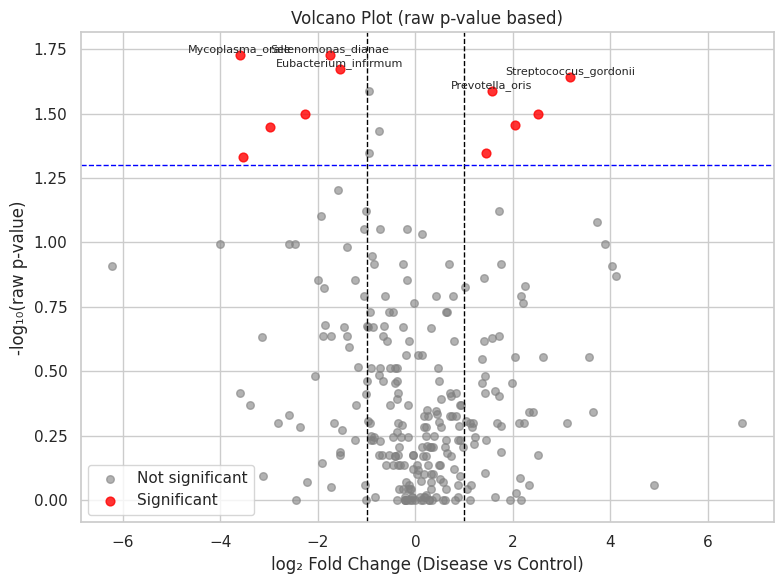

✅ Volcano plot saved to: /content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/volcano_plot_batch3_subq4.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file generated from previous step
file_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/diff_abundance_stats_batch3_with_log2FC.csv"
df = pd.read_csv(file_path, index_col=0)

# Minimal sanity check
print(f"Loaded table: {df.shape[0]} species, columns: {list(df.columns)}")

# Drop rows with missing p/q values or log2FC
df = df.dropna(subset=['p_value', 'q_value', 'log2FC']).copy()

# Step 1: Choose whether to use q_value or p_value
sig_q = (df['q_value'] < 0.05) & (df['log2FC'].abs() >= 1)
num_sig_q = sig_q.sum()

if num_sig_q >= 10:
    df['sig'] = sig_q
    df['p_for_plot'] = df['q_value']
    sig_type = 'Q-value'
else:
    sig_p = (df['p_value'] < 0.05) & (df['log2FC'].abs() >= 1)
    df['sig'] = sig_p
    df['p_for_plot'] = df['p_value']
    sig_type = 'raw p-value'

print(f"Using {sig_type} for significance criterion.")
print(f"Significant species found: {df['sig'].sum()}")

# Step 2: Compute -log10 for plotting
df['neg_log10_p'] = -np.log10(df['p_for_plot'])

# Step 3: Make the volcano plot
plt.figure(figsize=(8,6))
plt.scatter(df.loc[~df['sig'], 'log2FC'], df.loc[~df['sig'], 'neg_log10_p'],
            color='gray', alpha=0.6, s=30, label='Not significant')

plt.scatter(df.loc[df['sig'], 'log2FC'], df.loc[df['sig'], 'neg_log10_p'],
            color='red', alpha=0.8, s=40, label='Significant')

# Add threshold lines
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--', linewidth=1)

# Optional: annotate top few points
top_species = df[df['sig']].sort_values('p_for_plot').head(5)
for i, row in top_species.iterrows():
    plt.text(row['log2FC'], row['neg_log10_p'], i, fontsize=8, ha='center', va='bottom')

plt.xlabel('log₂ Fold Change (Disease vs Control)')
plt.ylabel(f'-log₁₀({sig_type})')
plt.title(f'Volcano Plot ({sig_type} based)')
plt.legend()
plt.tight_layout()

# Save plot
plot_path = "/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/volcano_plot_batch3_subq4.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Volcano plot saved to: {plot_path}")


# Goal 3: Boxplots for Top 4 Species in Each Direction of Fold Change

Top positive log2FC species: ['Lactobacillus_delbrueckii', 'Acidithiobacillus_thiooxidans', 'Lactobacillus_fermentum', 'Parascardovia_denticolens']
Top negative log2FC species: ['Moraxella_bovoculi', 'Neisseria_lactamica', 'Streptococcus_oligofermentans', 'Peptoniphilus_koenoeneniae']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-973876492.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_condition', y='abundance', data=data, palette='Set2', ax=ax)
/tmp/ipython-input-973876492.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='study_condition', y='abundance', data=data, palette='Set2', ax=ax)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: De

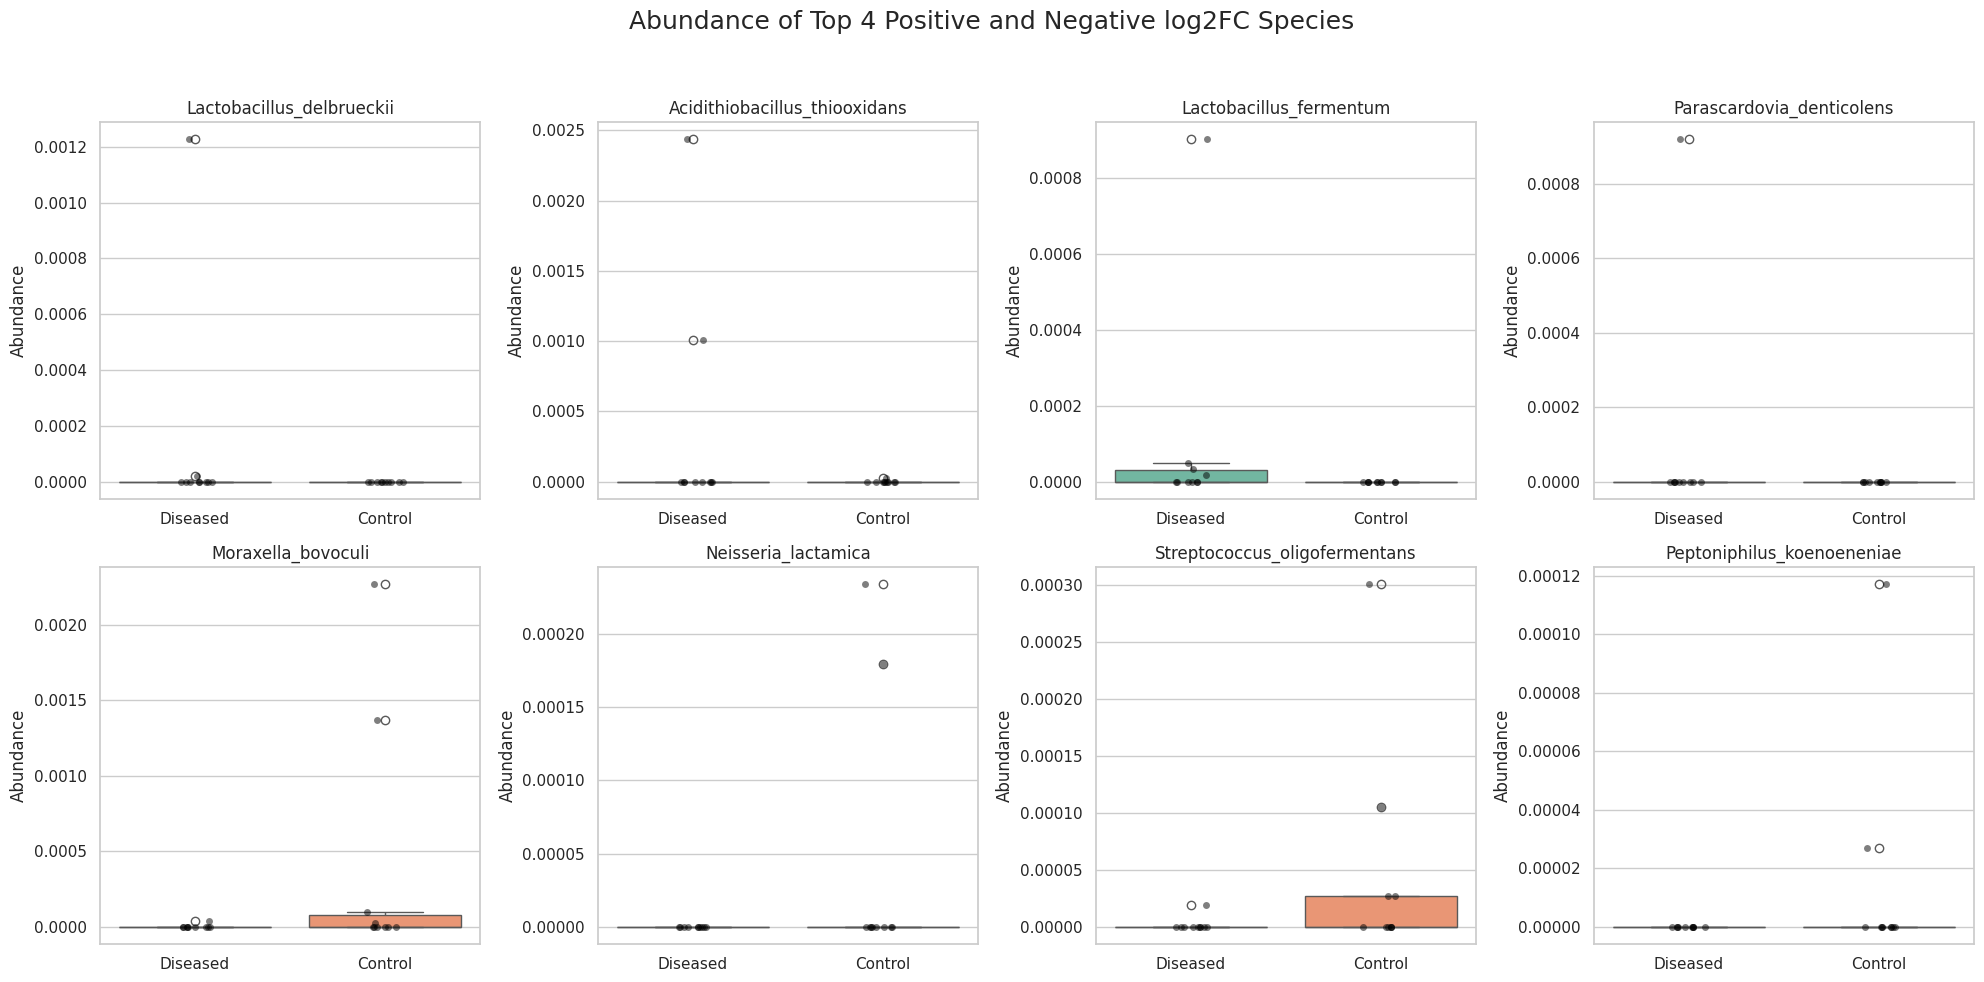

In [ ]:
# --- Step 1: Identify top species ---
top_positive = diff_abundance_stats_subq1.sort_values("log2FC", ascending=False).head(4).index.tolist()
top_negative = diff_abundance_stats_subq1.sort_values("log2FC", ascending=True).head(4).index.tolist()
all_top_species = top_positive + top_negative

print("Top positive log2FC species:", top_positive)
print("Top negative log2FC species:", top_negative)

# --- Step 2: Prepare long-format abundance data ---
# abundance_df: rows = sample_id, columns = species
abundance_subset = abundance_df[all_top_species].copy()
abundance_subset['sample_id'] = abundance_subset.index

# Melt to long format
abundance_long = abundance_subset.melt(id_vars='sample_id', var_name='species', value_name='abundance')

# Merge with batch_df to get Control/Disease info
abundance_long = abundance_long.merge(batch_df[['sample_id', 'study_condition']], on='sample_id')

# --- Step 3: Plot 2x4 grid of boxplots ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sp in enumerate(all_top_species):
    ax = axes[i]
    data = abundance_long[abundance_long['species'] == sp]

    # Boxplot
    sns.boxplot(x='study_condition', y='abundance', data=data, palette='Set2', ax=ax)

    # Overlay individual points
    sns.stripplot(x='study_condition', y='abundance', data=data, color='black', alpha=0.5, ax=ax)

    ax.set_title(sp)
    ax.set_xlabel('')
    ax.set_ylabel('Abundance')

plt.suptitle('Abundance of Top 4 Positive and Negative log2FC Species', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/content/drive/MyDrive/Assignments/CoMeG/assignment_2/q3/boxplot_top4_logfc.png", dpi=300)
plt.show()
